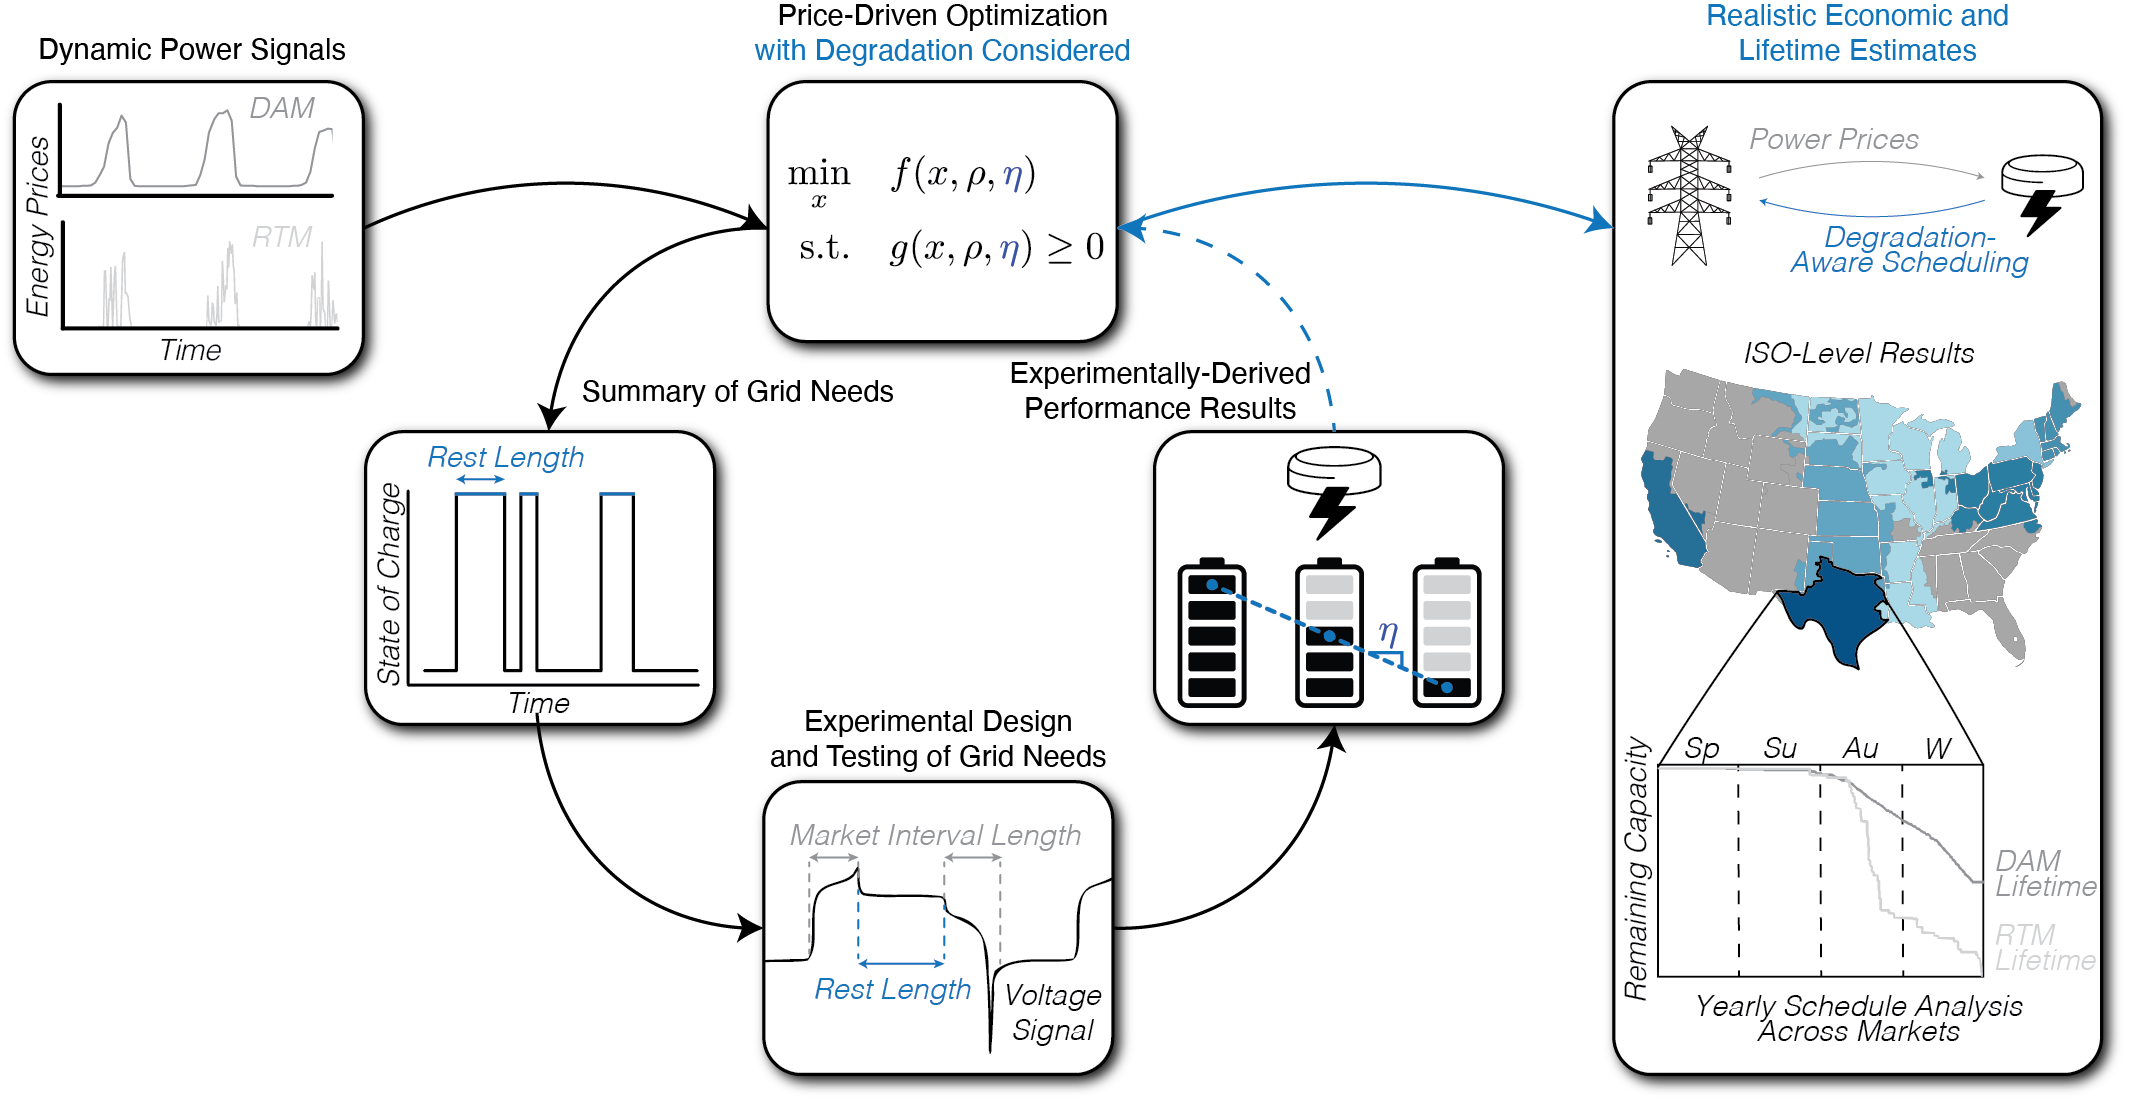

## Loading PJM LMP Data (2023)

In [ ]:
using CSV, LinearAlgebra, DataFrames, NamedArrays

LMP_vec = CSV.read("PJM_DAM_formatted.csv",DataFrame,header=true)
LMP = Vector(LMP_vec[:,2])

LMP_RTM_vec = CSV.read("PJM_RTM_formatted.csv",DataFrame,header=true)
LMP_RTM = Vector(LMP_RTM_vec[:,2])

n = length(LMP)
t = Vector(1:n) 
;

## Loading CAISO LMP Data (2023)

In [ ]:
using CSV, LinearAlgebra, DataFrames, NamedArrays, Statistics

LMP_vec = CSV.read("CAISO_DAM_formatted.csv",DataFrame,header=true)
LMP = Vector(LMP_vec[:,2])

LMP_RTM_vec = CSV.read("CAISO_RTM_formatted.csv",DataFrame,header=true)
LMP_RTM = Vector(LMP_RTM_vec[:,2])

n = length(LMP)
t = Vector(1:n) 
;

## Loading ERCOT LMP Data (2023, ERCOT Panhandle)

In [ ]:
using CSV, LinearAlgebra, DataFrames, NamedArrays

LMP_vec = CSV.read("ERCOT_DAM_formatted.csv",DataFrame,header=true)
LMP = Vector(LMP_vec[:,2])

LMP_RTM_vec = CSV.read("ERCOT_RTM_formatted.csv",DataFrame,header=true)
LMP_RTM = Vector(LMP_RTM_vec[1:35040,2])

n = length(LMP)
nRTM = length(LMP_RTM)
t = Vector(1:n) 
tRTM = Vector(1:nRTM)
;

## Loading MISO LMP Data (2023)

In [ ]:
using CSV, LinearAlgebra, DataFrames, NamedArrays

LMP_vec = CSV.read("MISO_DAM_formatted.csv",DataFrame,header=true)
LMP = Vector(LMP_vec[:,2])

LMP_RTM_vec = CSV.read("MISO_RTM_formatted.csv",DataFrame,header=true)
LMP_RTM = Vector(LMP_RTM_vec[:,2])

n = length(LMP)
t = Vector(1:n) 
;

## Loading SPP LMP Data (2023)

In [ ]:
using CSV, LinearAlgebra, DataFrames, NamedArrays

LMP_vec = CSV.read("SPP_DAM_formatted.csv",DataFrame,header=true)
LMP = Vector(LMP_vec[:,2])

LMP_RTM_vec = CSV.read("SPP_RTM_formatted.csv",DataFrame,header=true)
LMP_RTM = Vector(LMP_RTM_vec[:,2])

n = length(LMP)
t = Vector(1:n) 
;

## Loading ISO-NE LMP Data (2023)

In [ ]:
using CSV, LinearAlgebra, DataFrames, NamedArrays

LMP_vec = CSV.read("ISONE_DAM_formatted.csv",DataFrame,header=true)
LMP = Vector(LMP_vec[:,2])

LMP_RTM_vec = CSV.read("ISONE_RTM_formatted.csv",DataFrame,header=true)
LMP_RTM = Vector(LMP_RTM_vec[:,2])

n = length(LMP)
t = Vector(1:n) 
;

## Loading NYISO LMP Data (2023)

In [ ]:
using CSV, LinearAlgebra, DataFrames, NamedArrays

LMP_vec = CSV.read("NYISO_DAM_formatted.csv",DataFrame,header=true)
LMP = Vector(LMP_vec[:,2])

LMP_RTM_vec = CSV.read("NYISO_RTM_formatted.csv",DataFrame,header=true)
LMP_RTM = Vector(LMP_RTM_vec[:,2])

n = length(LMP)
t = Vector(1:n) 
;

## DAM Optimal Scheduling without Degradation

In [ ]:
using JuMP, Gurobi, PyPlot, DelimitedFiles

function BatteryOptimSchOnlyDAM(min_cap, ramp_down, ramp_up, min_nominal, max_nominal)

    m = Model(Gurobi.Optimizer)
    
    # Defining Model Variables
    
    @variable(m, MW_bought[1:n] >= 0)
    @variable(m, cost_operating[1:n])
    @variable(m, MW_sold[1:n] >= 0)
    @variable(m, SOC[1:n] >= 0)
    
    # Defining Contraints: Net operating costs when considering DAM purchases and sales
    
    @constraint(m, cost_operating .== LMP.*(MW_bought) .- LMP.*MW_sold)

    # Defining Constraints: Keeping minimal operating within some perceentage of the nominal capacity (not active for paper results)
    
    @constraint(m, MW_bought .>= min_cap)

    # Defining Constraints: State of charge tracking and physical limitations (first time interval)

    @constraint(m, SOC[1] == MW_bought[1] .- MW_sold[1])
    @constraint(m, SOC .<= max_nominal)

    #Defining Constraints: State of charge tracking and physical limitations and ramping considerations (consecutive time intervals)
    
    for i in 2:n
        @constraint(m, SOC[i] .== MW_bought[i] .+ SOC[i-1] .- MW_sold[i])
        @constraint(m, SOC[i] .- SOC[i-1] .<= ramp_up*max_nominal)
        @constraint(m, SOC[i] .- SOC[i-1] .>= ramp_down*max_nominal)
    end

    # Model Objective: Minimize net costs (or, maximize net revenue)

    @objective(m, Max, -1*sum(cost_operating))

    # Model Solution

    set_silent(m)
    optimize!(m)

    # Exporting model results
    
    df = DataFrame(time = t,
                   megawatts_DAM = value.(MW_bought),
                   megawatts_SoldToDAM = value.(MW_sold),
                   megawatts_totalStoredInBattery = value.(SOC)
                   )
    
    CSV.write("BatteryInDAM_ModelResults_NoDegradation.csv", df)

;
    
end
;

## RTM Optimal Scheduling without Degradation

In [ ]:
using JuMP, Gurobi, PyPlot, DelimitedFiles

function BatteryOptimSchOnlyRTM(min_cap, ramp_down, ramp_up, min_nominal, max_nominal)

    m = Model(Gurobi.Optimizer)

    # Modifying model time horizon from DAM to RTM length
    
    k = n*4 # for all ISOs that are not ERCOT, instead use k = n*12
    
    # Defining Model Variables
    
    @variable(m, MW_bought[1:k] >= 0)
    @variable(m, cost_operating[1:k])
    @variable(m, MW_sold[1:k] >= 0)
    @variable(m, SOC[1:k] >= 0)
    
    # Defining Contraints: Net operating costs when considering RTM purchases and sales
    
    @constraint(m, cost_operating .== LMP_RTM.*(MW_bought) .- LMP_RTM.*MW_sold)

    # Defining Constraints: Keeping minimal operating within some perceentage of the nominal capacity (not active for paper results)
    
    @constraint(m, MW_bought .>= min_cap)

    # Defining Constraints: State of charge tracking and physical limitations (first time interval)
    
    @constraint(m, SOC[1] == MW_bought[1] .- MW_sold[1])
    @constraint(m, SOC .<= max_nominal)

    #Defining Constraints: State of charge tracking and physical limitations and ramping considerations (consecutive time intervals)
    
    for i in 2:k
        @constraint(m, SOC[i] .== MW_bought[i] .+ SOC[i-1] .- MW_sold[i])
        @constraint(m, SOC[i] .- SOC[i-1] .<= ramp_up*max_nominal)
        @constraint(m, SOC[i] .- SOC[i-1] .>= ramp_down*max_nominal)
    end

    # Model Objective: Minimize net costs (or, maximize net revenue)

    @objective(m, Max, -1*sum(cost_operating))

    # Model Solution

    set_silent(m)
    optimize!(m)

    # Exporting model results

    df = DataFrame(megawatts_RTM = value.(MW_bought),
                   megawatts_SoldToRTM = value.(MW_sold),
                   megawatts_totalStoredInBattery = value.(SOC)
                   )
    
    CSV.write("BatteryInRTM_ModelResults_NoDegradation.csv", df)

;
    
end
;

## DAM Optimal Scheduling with Degradation

In [ ]:
using JuMP, Gurobi, PyPlot, DelimitedFiles

function BatteryOptimSchOnlyDAMwDegrad(min_cap, ramp_down, ramp_up, min_nominal, max_nominal)

    m = Model(Gurobi.Optimizer)
    
    # Defining Model Variables
    
    @variable(m, MW_bought[1:n] >= 0)
    @variable(m, cost_operating[1:n])
    @variable(m, MW_sold[1:n] >= 0)
    @variable(m, SOC[1:n] >= 0)

    # New variables relevant to degradation tracking and capacity reduction

    @variable(m, z_bought[1:n], Bin)
    @variable(m, z_sold[1:n], Bin)
    @variable(m, z_empty[1:n], Bin)
    @variable(m, z_rest[1:n], Bin)
    @variable(m, capacity[1:n] >= 0)

    # New constants relevant to degradation tracking and capacity reduction

    deg_mileage = 0.0021
    deg_rest = [0.00204836, 0.009448622, 0.010123019]
    ε = 1e-6
    
    # Defining Contraints: Net operating costs when considering DAM purchases and sales
    
    @constraint(m, cost_operating .== LMP.*(MW_bought) .- LMP.*MW_sold)
    
    # Defining Constraints: Creating an indicator that tells us if we are buying power from DAM
    
    @constraint(m, MW_bought .>=  ε*z_bought)
    @constraint(m, MW_bought .- ε .<= (max_nominal+ε)*z_bought)

    # Defining Constraints: Creating an indicator that tells us if we are selling power to DAM
   
    @constraint(m, MW_sold .>= ε*z_sold)
    @constraint(m, MW_sold .- ε .<= (max_nominal+ε)*z_sold)

    # Defining Constraints: Ensuring that indicators equate to one of four operating states (buying, selling, resting with charge held, or resting with no energy stored)

    @constraint(m, z_bought .+ z_sold .+ z_rest .+ z_empty .== 1)

    # Defining Constraints: Keeping minimal operating within some percentage of the nominal capacity
    
    @constraint(m, MW_bought .>= min_cap*max_nominal)

    # Defining Constraints: State of charge tracking (first time interval)
    
    @constraint(m, SOC[1] == MW_bought[1] .- MW_sold[1])

    # Defining Constraints: Capacity with respect to operating decisions (first time interval)

    @constraint(m, capacity[1] == max_nominal)

    # Defining Constraints: Creating an indicator that tells us if our battery is empty (working in combination with the four-mode state tracking constraint above)

    @constraint(m, SOC .- ε >= -1*ε*z_empty .+ 0.5*ε*(1.0 .- z_empty))

    # Defining Constraints: State of charge tracking and physical limitations and ramping considerations (consecutive time intervals)

    @constraint(m, SOC .<= capacity)

    for i in 2:n
        @constraint(m, SOC[i] .== MW_bought[i] .+ SOC[i-1] .- MW_sold[i])
        @constraint(m, SOC[i] .- SOC[i-1] .<= ramp_up*max_nominal)
        @constraint(m, SOC[i] .- SOC[i-1] .>= ramp_down*max_nominal)

        # Defining Constraints: Capacity will decay with respect to both the amount of power purchased and the amount of time rest has cost_operatingcured with charge held

        @constraint(m, capacity[i] .== capacity[i-1] .- deg_mileage*max_nominal*MW_bought[i-1] .- deg_rest[1]*(1 .- z_bought[i-1] .+ z_sold[i-1] .+ z_empty[i-1]))

    end

    # Model Objective: Minimize net costs (or, maximize net revenue)

    @objective(m, Max, -1*sum(cost_operating))

    # Model Solution

    set_silent(m)
    optimize!(m)

    # Exporting model results

    df = DataFrame(time = t,
                   megawatts_DAM = value.(MW_bought),
                   megawatts_SoldToDAM = value.(MW_sold),
                   megawatts_totalStoredInBattery = value.(SOC),
                   max_cap = value.(capacity)
                   )
    
    CSV.write("BatteryInDAM_ModelResults_WithDegradation.csv", df)

    # Specifically assigning value to the resultant yearly economic value (to be used in evaluating decaying economic value over ramp rates)

    y = objective_value(m)

;
    
end
;

## RTM Optimal Scheduling with Degradation

In [ ]:
using JuMP, Gurobi, PyPlot, DelimitedFiles

function BatteryOptimSchOnlyRTMwDegrad(min_cap, ramp_down, ramp_up, min_nominal, max_nominal)

    m = Model(Gurobi.Optimizer)

    # MIP Gap: for RTM case studies, gap was set to 1% for solution time considerations

    set_optimizer_attribute(m, "MIPGap", 0.01) # 1% optimality gap
    
    # Defining Model Variables
    
    @variable(m, MW_bought[1:nRTM] >= 0)
    @variable(m, cost_operating[1:nRTM])
    @variable(m, MW_sold[1:nRTM] >= 0)
    @variable(m, SOC[1:nRTM] >= 0)

    # New variables relevant to degradation tracking and capacity reduction

    @variable(m, z_bought[1:nRTM], Bin)
    @variable(m, z_sold[1:nRTM], Bin)
    @variable(m, z_empty[1:nRTM], Bin)
    @variable(m, z_rest[1:nRTM], Bin)
    @variable(m, capacity[1:nRTM] >= 0)

    # New constants relevant to degradation tracking and capacity reduction

    deg_mileage = 0.0021
    deg_rest = [0.002439152, 0.00283409, 0.003314993, 0.006022777, 0.006054991]
    ε = 1e-6
    
    # Defining Contraints: Net operating costs when considering RTM purchases and sales
    
    @constraint(m, cost_operating .== LMP_RTM.*(MW_bought) .- LMP_RTM.*MW_sold)
    
    # Defining Constraints: Creating an indicator that tells us if we are buying power from RTM
    
    @constraint(m, MW_bought .>= ε*z_bought)
    @constraint(m, MW_bought .- ε .<= (max_nominal+ε)*z_bought)

    # NEW STUFF
    # Defining Constraints: Creating an indicator that tells us if we are selling power to RTM
   
    @constraint(m, MW_sold .>= ε*z_sold)
    @constraint(m, MW_sold .- ε .<= (max_nominal+ε)*z_sold)

    # Defining Constraints: Ensuring that indicators equate to one of four operating states (buying, selling, resting with charge held, or resting with no energy stored)

    @constraint(m, z_bought .+ z_sold .+ z_rest .+ z_empty .== 1)

    # Defining Constraints: Keeping minimal operating within some percentage of the nominal capacity
    
    @constraint(m, MW_bought .>= min_cap*max_nominal)

    # Defining Constraints: State of charge tracking (first time interval)
    
    @constraint(m, SOC[1] == MW_bought[1] .- MW_sold[1])

    # Defining Constraints: Capacity with respect to operating decisions (first time interval)

    @constraint(m, capacity[1] == max_nominal)

    # Defining Constraints: Creating an indicator that tells us if our battery is empty (working in combination with the four-mode state tracking constraint above)
    
    @constraint(m, SOC .- ε >= -1*ε*z_empty .+ 0.5*ε*(1.0 .- z_empty))

    # Defining Constraints: State of charge tracking and physical limitations and ramping considerations (consecutive time intervals)

    @constraint(m, SOC .<= capacity)
    
    for i in 2:nRTM
        @constraint(m, SOC[i] .== MW_bought[i] .+ SOC[i-1] .- MW_sold[i])
        @constraint(m, SOC[i] .- SOC[i-1] .<= ramp_up*max_nominal)
        @constraint(m, SOC[i] .- SOC[i-1] .>= ramp_down*max_nominal)

        # Defining Constraints: Capacity will decay with respect to both the amount of power purchased and the amount of time rest has cost_operatingcured with charge held

        @constraint(m, capacity[i] .== capacity[i-1] .- deg_mileage*max_nominal*MW_bought[i-1] .- deg_rest[1]*(1 .- z_bought[i-1] .+ z_sold[i-1] .+ z_empty[i-1]))

    end

   # Model Objective: Minimize net costs (or, maximize net revenue)

    @objective(m, Max, -1*sum(cost_operating))

    # Model Solution
    
    set_silent(m)
    optimize!(m)

    # Exporting model results

    df = DataFrame(time = tRTM,
                   megawatts_RTM = value.(MW_bought),
                   megawatts_SoldToRTM = value.(MW_sold),
                   megawatts_totalStoredInBattery = value.(SOC),
                   max_cap = value.(capacity)
                   )
    
    CSV.write("BatteryInRTM_ModelResults_WithDegradation.csv", df)

    # Specifically assigning value to the resultant yearly economic value (to be used in evaluating decaying economic value over ramp rates)

    y = objective_value(m)

;
    
end
;

## Results: Optimal Scheduling and Capacity Loss During Market Participation

In [ ]:
# Relevant case study information:

min_cap = 0
ramp_down = -1
ramp_up = 1
min_nominal = 0
max_nominal = 1

# Creating Optimization Model

BatteryOptimSchOnlyDAMwDegrad(min_cap, ramp_down, ramp_up, min_nominal, max_nominal)
#BatteryOptimSchOnlyRTMwDegrad(min_cap, ramp_down, ramp_up, min_nominal, max_nominal)
;

## Results: Decay of Economic Value with Ramp Time

In [ ]:
min_cap = 0
ramp_down = -1
min_nominal = 0
max_nominal = 1

l = 1:24
y = zeros(length(l))

for i in l
    ramp_up = 1/i
    y[i] = BatteryOptimSchOnlyDAMwDegrad(min_cap, ramp_down, ramp_up, min_nominal, max_nominal)
    #y[i] = BatteryOptimSchOnlyRTMwDegrad(min_cap, ramp_down, ramp_up, min_nominal, max_nominal)
end
;